# MFA Analysis — 1000 components, rank 5

Visualizes results from `intrinsic_dims.pt` and `overlap.pt`.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

OUT = Path(".")  # run from experiments/out/1000_05/

dims_data = torch.load(OUT / "intrinsic_dims.pt", weights_only=False)
ov_data   = torch.load(OUT / "overlap.pt",        weights_only=False)

intrinsic_dims = dims_data["intrinsic_dims"]   # (K,)
cluster_sizes  = dims_data["cluster_sizes"]    # (K,)
K     = dims_data["K"]
rank  = dims_data["rank"]
D     = dims_data["D"]
thr   = dims_data["variance_threshold"]

kl_sym  = ov_data["kl_sym"]   # (K, K)
db      = ov_data["db"]
db_mean = ov_data["db_mean"]
db_cov  = ov_data["db_cov"]
bc      = ov_data["bc"]

# Upper-triangle flat arrays (off-diagonal pairs)
idx_i, idx_j = torch.triu_indices(K, K, offset=1)
kl_flat  = kl_sym[idx_i, idx_j]
db_flat  = db[idx_i, idx_j]
dbm_flat = db_mean[idx_i, idx_j]
dbc_flat = db_cov[idx_i, idx_j]
bc_flat  = bc[idx_i, idx_j]

valid = intrinsic_dims > 0
print(f"K={K}  rank(q)={rank}  D={D}  variance_threshold={thr}")
print(f"Clusters with data: {valid.sum().item()} / {K}")
print(f"Intrinsic dim — mean={intrinsic_dims[valid].float().mean():.1f}  "
      f"median={intrinsic_dims[valid].float().median():.1f}  "
      f"min={intrinsic_dims[valid].min().item()}  max={intrinsic_dims[valid].max().item()}")

K=1000  rank(q)=10  D=2048  variance_threshold=0.9
Clusters with data: 1000 / 1000
Intrinsic dim — mean=146.1  median=137.0  min=5  max=395


## 1. Intrinsic Dimensionality

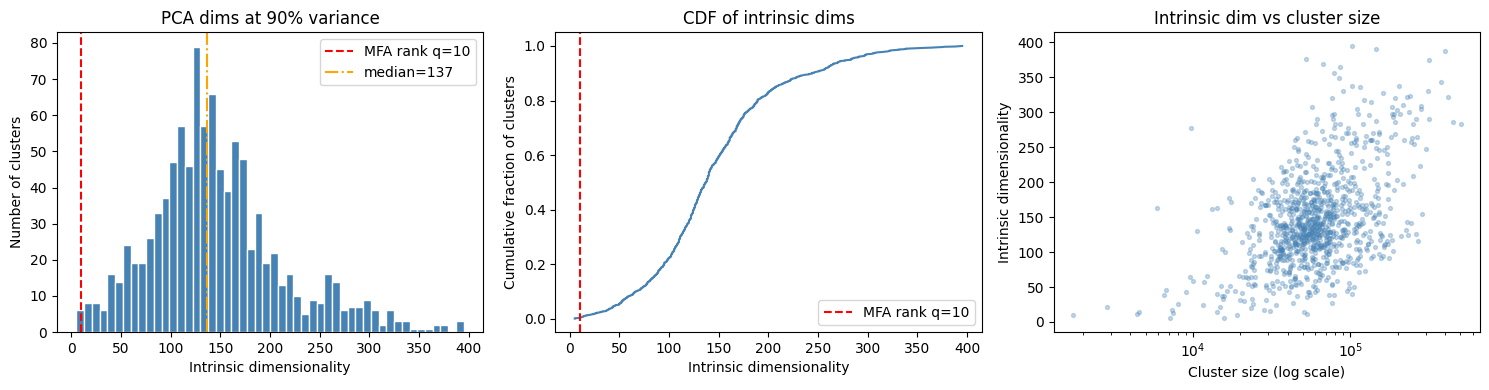

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Histogram of intrinsic dims ---
ax = axes[0]
vals = intrinsic_dims[valid].numpy()
ax.hist(vals, bins=50, color="steelblue", edgecolor="white")
ax.axvline(rank, color="red", linestyle="--", label=f"MFA rank q={rank}")
ax.axvline(float(np.median(vals)), color="orange", linestyle="-.", label=f"median={np.median(vals):.0f}")
ax.set_xlabel("Intrinsic dimensionality")
ax.set_ylabel("Number of clusters")
ax.set_title(f"PCA dims at {thr*100:.0f}% variance")
ax.legend()

# --- CDF ---
ax = axes[1]
sorted_vals = np.sort(vals)
cdf = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
ax.plot(sorted_vals, cdf, color="steelblue")
ax.axvline(rank, color="red", linestyle="--", label=f"MFA rank q={rank}")
ax.set_xlabel("Intrinsic dimensionality")
ax.set_ylabel("Cumulative fraction of clusters")
ax.set_title("CDF of intrinsic dims")
ax.legend()

# --- Intrinsic dim vs cluster size ---
ax = axes[2]
sizes = cluster_sizes[valid].numpy()
ax.scatter(sizes, vals, alpha=0.3, s=8, color="steelblue")
ax.set_xscale("log")
ax.set_xlabel("Cluster size (log scale)")
ax.set_ylabel("Intrinsic dimensionality")
ax.set_title("Intrinsic dim vs cluster size")

plt.tight_layout()
plt.savefig(OUT / "intrinsic_dims.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Cluster Size Distribution

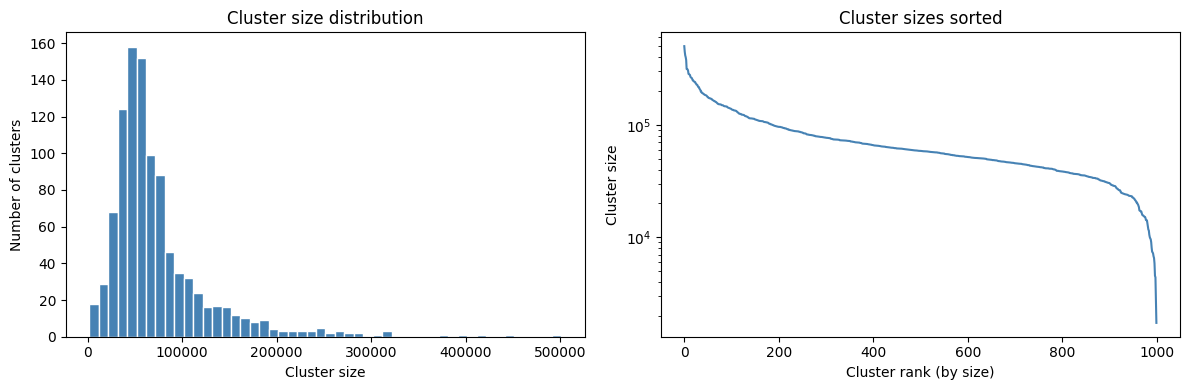

Cluster sizes — min=1734  max=501435  mean=73687.9  median=58662.0
Empty clusters: 0


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(cluster_sizes.numpy(), bins=50, color="steelblue", edgecolor="white")
ax.set_xlabel("Cluster size")
ax.set_ylabel("Number of clusters")
ax.set_title("Cluster size distribution")

ax = axes[1]
sorted_sizes = np.sort(cluster_sizes.numpy())[::-1]
ax.plot(sorted_sizes, color="steelblue")
ax.set_xlabel("Cluster rank (by size)")
ax.set_ylabel("Cluster size")
ax.set_title("Cluster sizes sorted")
ax.set_yscale("log")

plt.tight_layout()
plt.savefig(OUT / "cluster_sizes.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Cluster sizes — min={cluster_sizes.min().item()}  max={cluster_sizes.max().item()}  "
      f"mean={cluster_sizes.float().mean():.1f}  median={cluster_sizes.float().median():.1f}")
print(f"Empty clusters: {(cluster_sizes == 0).sum().item()}")

## 3. Overlap Metrics — Histograms

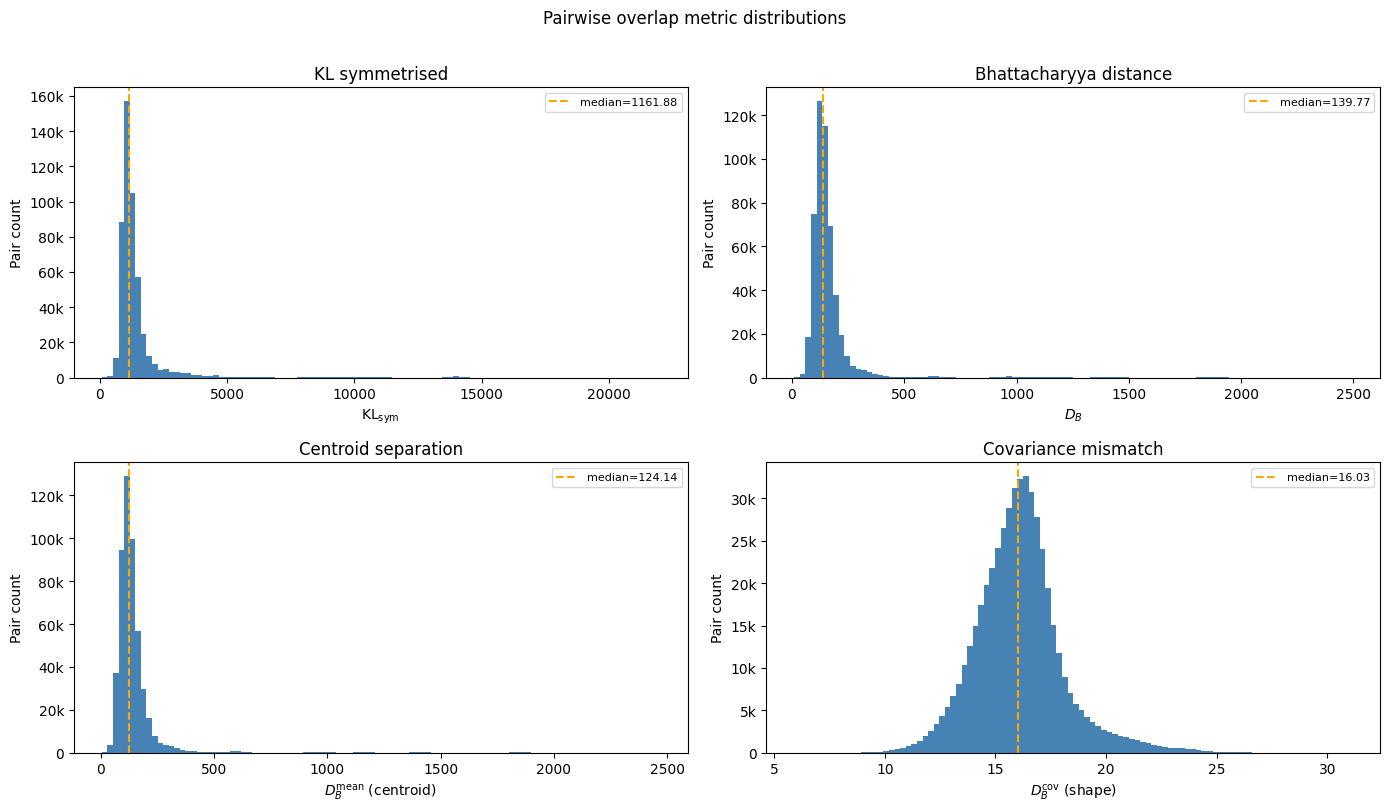

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

panels = [
    (axes[0, 0], kl_flat,  r"$\mathrm{KL}_{\mathrm{sym}}$",      "KL symmetrised"),
    (axes[0, 1], db_flat,  r"$D_B$",                               "Bhattacharyya distance"),
    (axes[1, 0], dbm_flat, r"$D_B^{\mathrm{mean}}$ (centroid)",   "Centroid separation"),
    (axes[1, 1], dbc_flat, r"$D_B^{\mathrm{cov}}$ (shape)",       "Covariance mismatch"),
]

for ax, flat, xlabel, title in panels:
    vals = flat.numpy()
    ax.hist(vals, bins=100, color="steelblue", edgecolor="none")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Pair count")
    ax.set_title(title)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k" if x >= 1000 else str(int(x))))
    med = float(np.median(vals))
    ax.axvline(med, color="orange", linestyle="--", label=f"median={med:.2f}")
    ax.legend(fontsize=8)

plt.suptitle("Pairwise overlap metric distributions", y=1.01)
plt.tight_layout()
plt.savefig(OUT / "overlap_histograms.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Overlap Heatmaps (hierarchically ordered)

In [5]:
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

# Use KL_sym as the distance for ordering (clip negatives from numerics)
kl_np = kl_sym.numpy()
kl_np = np.clip(kl_np, 0, None)
np.fill_diagonal(kl_np, 0)

# Condense — squareform expects a symmetric matrix
condensed = squareform(kl_np, checks=False)

# Cap very large values so linkage is numerically stable
condensed = np.clip(condensed, 0, np.percentile(condensed[condensed > 0], 99))

Z     = linkage(condensed, method="average")
order = leaves_list(Z)

print(f"Hierarchical ordering computed over {K} components")

Hierarchical ordering computed over 1000 components


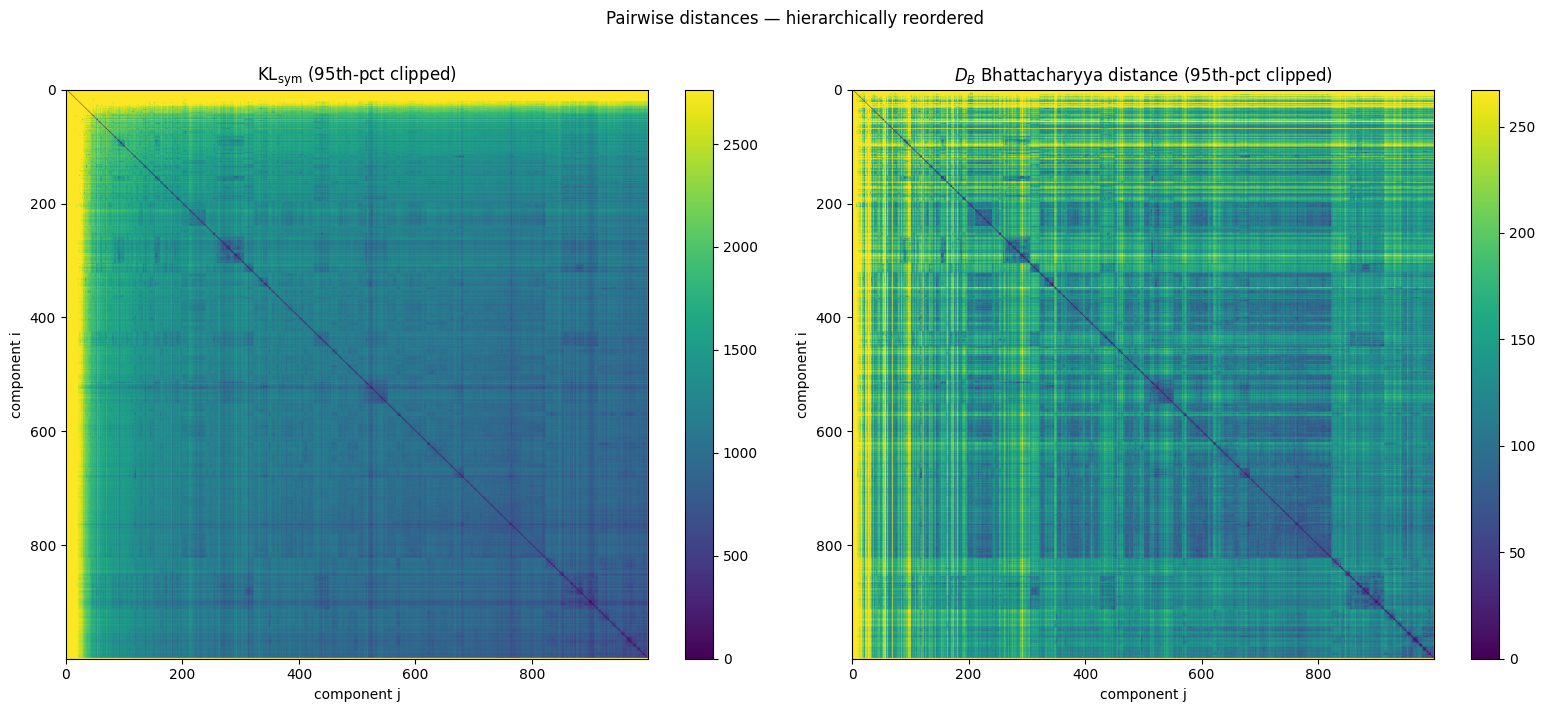

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# KL_sym heatmap
ax = axes[0]
mat = kl_sym[order][:, order].numpy()
vmax = np.percentile(mat[mat > 0], 95)
im = ax.imshow(mat, aspect="auto", cmap="viridis", vmin=0, vmax=vmax)
ax.set_title(r"$\mathrm{KL}_{\mathrm{sym}}$ (95th-pct clipped)")
ax.set_xlabel("component j")
ax.set_ylabel("component i")
plt.colorbar(im, ax=ax)

# D_B heatmap
ax = axes[1]
mat = db[order][:, order].numpy()
vmax = np.percentile(mat[mat > 0], 95)
im = ax.imshow(mat, aspect="auto", cmap="viridis", vmin=0, vmax=vmax)
ax.set_title(r"$D_B$ Bhattacharyya distance (95th-pct clipped)")
ax.set_xlabel("component j")
ax.set_ylabel("component i")
plt.colorbar(im, ax=ax)

plt.suptitle("Pairwise distances — hierarchically reordered", y=1.01)
plt.tight_layout()
plt.savefig(OUT / "overlap_heatmaps_dist.png", dpi=150, bbox_inches="tight")
plt.show()

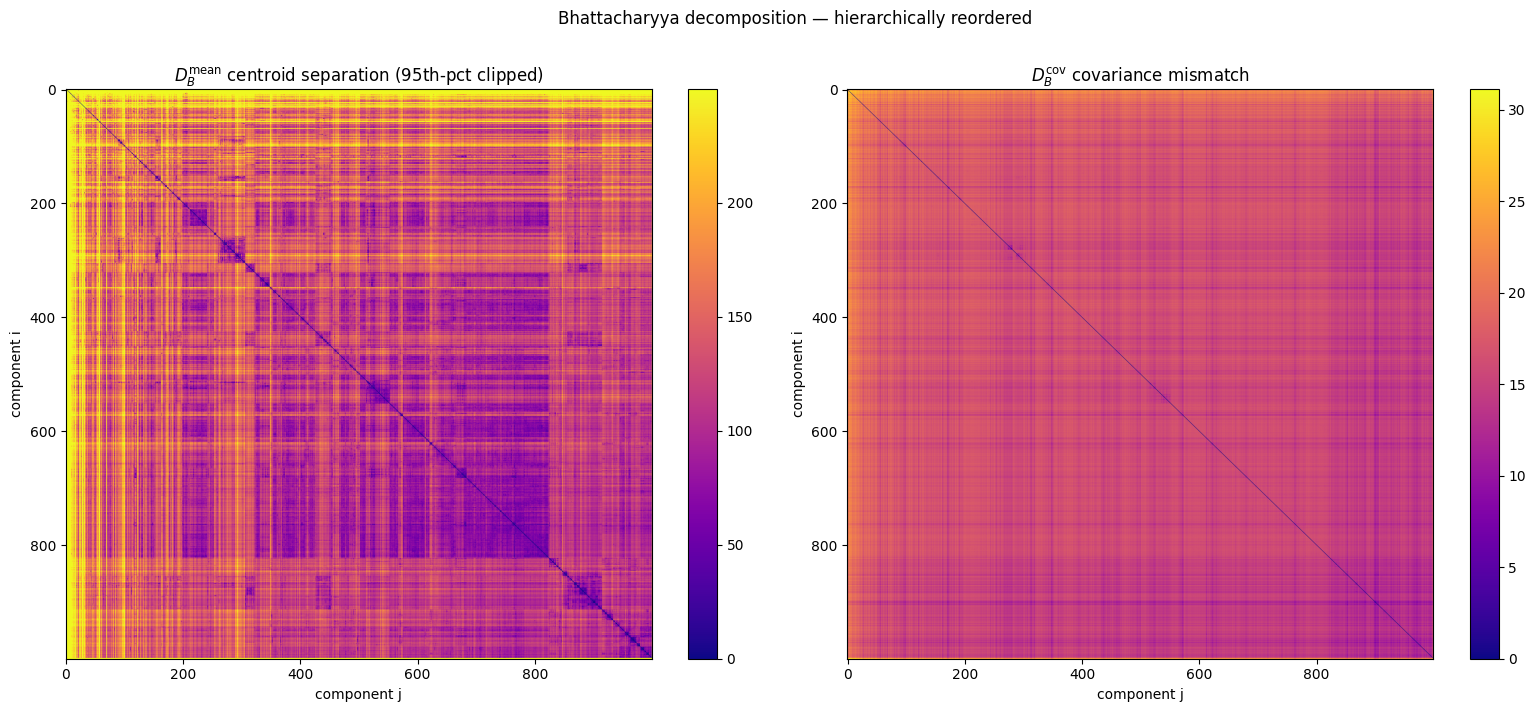

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# db_mean
ax = axes[0]
mat = db_mean[order][:, order].numpy()
vmax = np.percentile(mat[mat > 0], 95)
im = ax.imshow(mat, aspect="auto", cmap="plasma", vmin=0, vmax=vmax)
ax.set_title(r"$D_B^{\mathrm{mean}}$ centroid separation (95th-pct clipped)")
ax.set_xlabel("component j")
ax.set_ylabel("component i")
plt.colorbar(im, ax=ax)

# db_cov
ax = axes[1]
mat = db_cov[order][:, order].numpy()
im = ax.imshow(mat, aspect="auto", cmap="plasma")
ax.set_title(r"$D_B^{\mathrm{cov}}$ covariance mismatch")
ax.set_xlabel("component j")
ax.set_ylabel("component i")
plt.colorbar(im, ax=ax)

plt.suptitle("Bhattacharyya decomposition — hierarchically reordered", y=1.01)
plt.tight_layout()
plt.savefig(OUT / "overlap_heatmaps_bhatt.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Nearest-Neighbour Overlap Profile

For each component, what is its closest neighbour (in KL) and the Bhattacharyya coefficient to that neighbour?

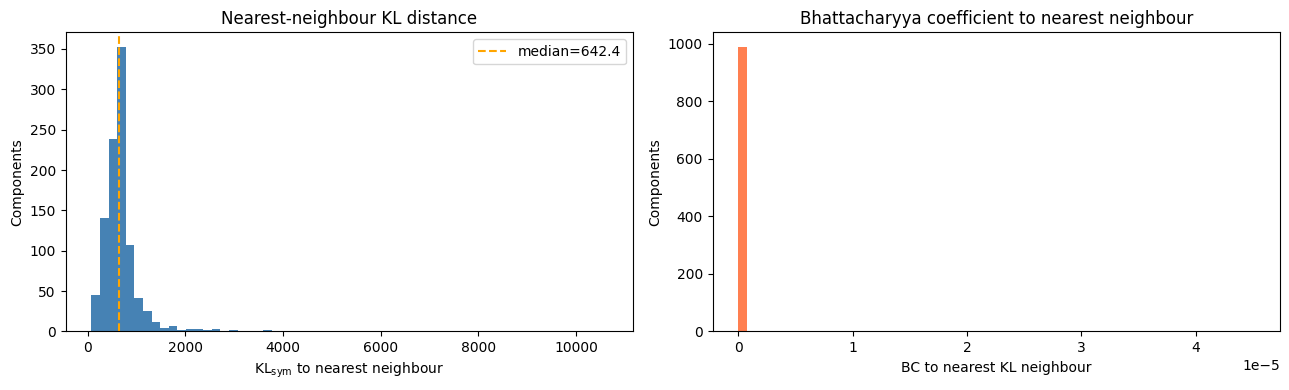

Nearest-neighbour KL — min=78.57  median=642.42  max=10642.43
BC to NN            — min=0.000000  max=0.000045


In [8]:
# Set diagonal to inf so argmin picks an actual neighbour
kl_nn = kl_sym.clone()
kl_nn.fill_diagonal_(float("inf"))
nn_kl, nn_idx = kl_nn.min(dim=1)

bc_nn = bc[torch.arange(K), nn_idx]  # BC to nearest KL neighbour

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(nn_kl.numpy(), bins=60, color="steelblue", edgecolor="none")
ax.set_xlabel(r"$\mathrm{KL}_{\mathrm{sym}}$ to nearest neighbour")
ax.set_ylabel("Components")
ax.set_title("Nearest-neighbour KL distance")
med = float(nn_kl.median())
ax.axvline(med, color="orange", linestyle="--", label=f"median={med:.1f}")
ax.legend()

ax = axes[1]
ax.hist(bc_nn.numpy(), bins=60, color="coral", edgecolor="none")
ax.set_xlabel("BC to nearest KL neighbour")
ax.set_ylabel("Components")
ax.set_title("Bhattacharyya coefficient to nearest neighbour")

plt.tight_layout()
plt.savefig(OUT / "nn_overlap.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Nearest-neighbour KL — min={nn_kl.min():.2f}  median={nn_kl.median():.2f}  max={nn_kl.max():.2f}")
print(f"BC to NN            — min={bc_nn.min():.6f}  max={bc_nn.max():.6f}")